### 1. Environment & Database Setup

**1.1 Import Libraries**

In [1]:
# Analysis Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Database Libraries
from sqlalchemy import create_engine, exc
import duckdb
import time

**1.2 Configrations**

In [2]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=exc.SAWarning)

# Display Options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

# Chart Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11
    })

**1.3 ETL — Load from PostgreSQL into DuckDB**

In [3]:
DB_PATH = '/run/media/hasan/Projects/Python & SQL/03. Toy Store E-Commerce Database/0. Dataset/Postgresql/my_analytics.db'
con_duck = duckdb.connect(database=DB_PATH)


try:
    con_duck.execute("INSTALL postgres; LOAD postgres;")
    pg_conn_str = "host=localhost dbname=toys_store_ecommerce user=postgres password=your_password"
    con_duck.execute(f"ATTACH '{pg_conn_str}' AS pg_source (TYPE POSTGRES);")
    tables = con_duck.execute("SELECT table_name FROM pg_source.information_schema.tables WHERE table_schema = 'public'").df()['table_name'].tolist()

    print("-" * 60)
    print(f"{'Table Name':<30} | {'Status':<10} | {'Duration':<12}")
    print("-" * 60)

    for table in tables:
        start_time = time.time()
        con_duck.execute(f'CREATE OR REPLACE TABLE "{table}" AS SELECT * FROM pg_source.public."{table}";')
        
        duration = time.time() - start_time
        print(f"{table:<30} | {'Success':<10} | {duration:>7.2f} sec")
finally:
    con_duck.execute("DETACH pg_source;")

------------------------------------------------------------
Table Name                     | Status     | Duration    
------------------------------------------------------------
order_item_refunds             | Success    |    0.10 sec
order_items                    | Success    |    0.30 sec
orders                         | Success    |    0.21 sec
products                       | Success    |    0.05 sec


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

website_pageviews              | Success    |    2.56 sec
website_sessions               | Success    |    1.95 sec


**1.4 Connect to DuckDB**

In [4]:
DB_PATH  = '/run/media/hasan/Projects/Python & SQL/03. Toy Store E-Commerce Database/0. Dataset/Postgresql/my_analytics.db'
con_duck = duckdb.connect(database=DB_PATH)
tables_list = con_duck.execute('SHOW TABLES').df()['name'].tolist()
print(f'Connected to: {DB_PATH}')
print(f'Tables found: {tables_list}')

Connected to: /run/media/hasan/Projects/Python & SQL/03. Toy Store E-Commerce Database/0. Dataset/Postgresql/my_analytics.db
Tables found: ['order_item_refunds', 'order_items', 'orders', 'products', 'website_pageviews', 'website_sessions']


### 2. EDA & Data Quality

**2.1 Database Overview — Table Size Summary**

In [13]:
info_table = [
    {
        'Table Name':   table,
        'Row Count':    con_duck.execute(f'SELECT COUNT(*) FROM {table}').fetchone()[0],
        'Column Count': len(con_duck.execute(f'DESCRIBE {table}').fetchall())
    }
    for table in tables_list
]

info_df = (pd.DataFrame(info_table).sort_values('Row Count', ascending=False).reset_index(drop=True))
display(info_df)

,Table Name,Row Count,Column Count
0,website_pageviews,1188124,4
1,website_sessions,472871,9
2,order_items,40025,7
3,orders,32313,8
4,order_item_refunds,1731,5
5,products,4,3


**2.2 Data Profiling & Cardinality**

In [14]:
cardinality = []

for table in tables_list:
    schema     = con_duck.execute(f'DESCRIBE {table}').fetchall()
    total_rows = con_duck.execute(f'SELECT COUNT(*) FROM {table}').fetchone()[0]
    
    for col_name, col_type, *_ in schema:
        unique = con_duck.execute(f'SELECT COUNT(DISTINCT {col_name}) FROM {table}').fetchone()[0]
        cardinality.append({
            'table': table,
            'column':col_name,
            'data_type': col_type,
            'unique_values': unique,
            'total_rows': total_rows
        })

cardinality_df = pd.DataFrame(cardinality)
cardinality_df.index += 1
display(cardinality_df)

,table,column,data_type,unique_values,total_rows
1,order_item_refunds,order_item_refund_id,INTEGER,1731,1731
2,order_item_refunds,created_at,VARCHAR,1731,1731
3,order_item_refunds,order_item_id,INTEGER,1731,1731
4,order_item_refunds,order_id,INTEGER,1723,1731
5,order_item_refunds,refund_amount_usd,FLOAT,4,1731
6,order_items,order_item_id,INTEGER,40025,40025
7,order_items,created_at,VARCHAR,32299,40025
8,order_items,order_id,INTEGER,32313,40025
9,order_items,product_id,INTEGER,4,40025
10,order_items,is_primary_item,INTEGER,2,40025


**2.3 Missing Values Audit**

In [15]:
print(f"{'Table Name':<25} | {'Column Name':<25} | {'Null Count'}")
print('-' * 70)

for table in tables_list:
    df = con_duck.execute(f'SELECT * FROM "{table}"').df()
    null_data = df.isnull().sum()    
    null_cols = null_data[null_data > 0]
    
    if not null_cols.empty:
        for col_name, count in null_cols.items():
            print(f"{table:<25} | {col_name:<25} | {count}")
    else:
        print(f"{table:<25} | {'(All Columns)':<25} | Clean ✅")

Table Name                | Column Name               | Null Count
----------------------------------------------------------------------
order_item_refunds        | (All Columns)             | Clean ✅
order_items               | (All Columns)             | Clean ✅
orders                    | (All Columns)             | Clean ✅
products                  | (All Columns)             | Clean ✅
website_pageviews         | (All Columns)             | Clean ✅
website_sessions          | (All Columns)             | Clean ✅


**2.4 Duplicate Records Check**

In [16]:
print(f"{'Table Name':<25} | {'Status':<25} | {'Duplicate Count'}")
print('-' * 75)

for table in tables_list:
    dup_count = con_duck.execute(f'SELECT COUNT(*) - COUNT(DISTINCT COLUMNS(*)) FROM {table}').fetchone()[0]
    status    = 'Clean ✅' if dup_count == 0 else 'Duplicates Found ❌'
    print(f"{table:<25} | {status:<25} | {dup_count}")

Table Name                | Status                    | Duplicate Count
---------------------------------------------------------------------------
order_item_refunds        | Clean ✅                   | 0
order_items               | Clean ✅                   | 0
orders                    | Clean ✅                   | 0
products                  | Clean ✅                   | 0
website_pageviews         | Clean ✅                   | 0
website_sessions          | Clean ✅                   | 0


**2.5 Temporal Coverage**

In [17]:
date_summary = []

for table in tables_list:
    columns = [col[0] for col in con_duck.execute(f'DESCRIBE {table}').fetchall()]
    
    if 'created_at' in columns:
        start, end = con_duck.execute(f'SELECT MIN(created_at), MAX(created_at) FROM {table}').fetchone()
    else:
        start, end = None, None
    date_summary.append({'Table Name': table, 'Start Date': start, 'End Date': end})

display(pd.DataFrame(date_summary))

,Table Name,Start Date,End Date
0,order_item_refunds,2012-04-06 11:32:43,2015-04-01 18:11:08
1,order_items,2012-03-19 10:42:46,2015-03-19 05:38:31
2,orders,2012-03-19 10:42:46,2015-03-19 05:38:31
3,products,2012-03-19 08:00:00,2014-02-05 10:00:00
4,website_pageviews,2012-03-19 08:04:16,2015-03-19 07:59:32
5,website_sessions,2012-03-19 08:04:16,2015-03-19 07:59:08


### 3. Descriptive Statistics & Business Rules Validation

**3.1 Outlier Analysis (IQR Method)**

In [11]:
outliers_results = []
exclude_cols     = ['id', 'is_', '_id']

for table in tables_list:
    cols_info    = con_duck.execute(f'DESCRIBE {table}').df()
    numeric_cols = cols_info.loc[
        cols_info['column_type'].str.contains('INT|FLOAT|DOUBLE', case=False), 'column_name'
    ].tolist()
    valid_cols = [c for c in numeric_cols if not any(e in c.lower() for e in exclude_cols)]

    for col in valid_cols:
        res = con_duck.execute(f"""
            WITH Stats AS (
                SELECT 
                    quantile_cont("{col}", 0.25) AS q1,
                    quantile_cont("{col}", 0.75) AS q3,
                    COUNT(*) AS total
                FROM "{table}"
            ),
            Boundaries AS (
                SELECT
                    q1 - 1.5 * (q3 - q1) AS lower_limit,
                    q3 + 1.5 * (q3 - q1) AS upper_limit,
                    total
                FROM Stats
            )
        SELECT 
            COUNT(*),
            COUNT(*) * 100.0 / FIRST(total)
        FROM "{table}", Boundaries WHERE "{col}" < lower_limit OR "{col}" > upper_limit
        """).fetchone()

        outliers_results.append({
            'Table': table,
            'Column': col,
            'Outliers_Count': res[0],
            'Outlier_Percentage': round(res[1], 2)})

outliers_df = (pd.DataFrame(outliers_results).sort_values('Outliers_Count', ascending=False).reset_index(drop=True))
outliers_df.index += 1
display(outliers_df)

,Table,Column,Outliers_Count,Outlier_Percentage
1,order_items,price_usd,15799,39.47
2,order_items,cogs_usd,15799,39.47
3,orders,cogs_usd,9623,29.78
4,orders,price_usd,8246,25.52
5,orders,items_purchased,7712,23.87
6,order_item_refunds,refund_amount_usd,494,28.54


**Chart — Outlier Percentage by Column**

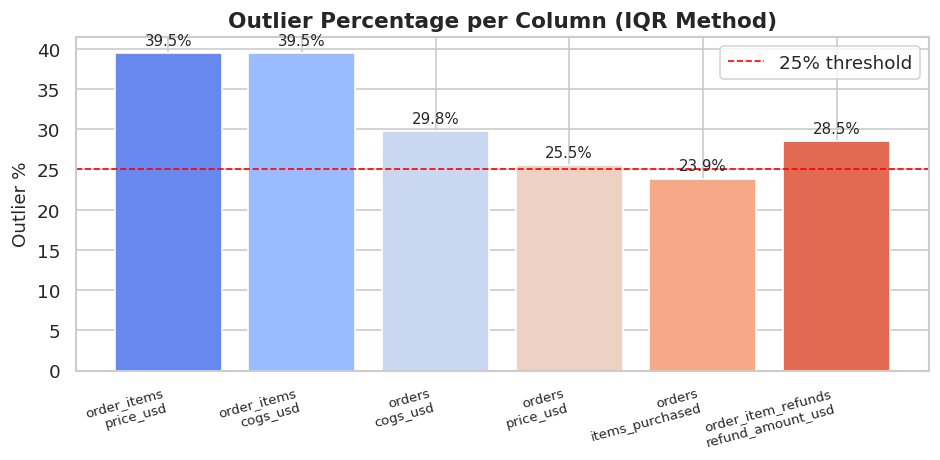

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
labels  = outliers_df['Table'] + '\n' + outliers_df['Column']
bars    = ax.bar(labels, outliers_df['Outlier_Percentage'],
                 color=sns.color_palette('coolwarm', len(outliers_df)))
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_ylabel('Outlier %')
ax.set_title('Outlier Percentage per Column (IQR Method)', fontweight='bold')
ax.axhline(25, color='red', linestyle='--', linewidth=1, label='25% threshold')
ax.legend()
plt.xticks(rotation=15, ha='right', fontsize=8)
plt.tight_layout(); plt.show()

**3.2 Business Rules & Logic Validation**

In [13]:
# 1. Negative prices
r1 = con_duck.execute('SELECT COUNT(*) FROM order_items WHERE price_usd < 0').fetchone()[0]
print(f"{'1. Negative Price Check':<30}: {'PASS' if r1==0 else 'FAIL'} ({r1} issues)")

# 2. Refund exceeds price
r2 = con_duck.execute("""
    SELECT COUNT(*) FROM order_item_refunds r
    JOIN order_items oi ON r.order_item_id = oi.order_item_id
    WHERE r.refund_amount_usd > oi.price_usd
""").fetchone()[0]
print(f"{'2. Refund Validation Check':<30}: {'PASS' if r2==0 else 'FAIL'} ({r2} issues)")

# 3. Orphan refunds
r3 = con_duck.execute("""
    SELECT COUNT(*) FROM order_item_refunds r
    LEFT JOIN order_items oi ON r.order_item_id = oi.order_item_id
    WHERE oi.order_item_id IS NULL
""").fetchone()[0]
print(f"{'3. Orphan Refund Check':<30}: {'PASS' if r3==0 else 'FAIL'} ({r3} issues)")

# 4. Loss-making products
r4 = con_duck.execute('SELECT COUNT(*) FROM order_items WHERE cogs_usd > price_usd').fetchone()[0]
print(f"{'4. Loss Product Check':<30}: {'PASS' if r4==0 else 'WARNING'} ({r4} issues)")

# 5. Future dates
r5 = con_duck.execute('SELECT COUNT(*) FROM orders WHERE created_at > CURRENT_DATE').fetchone()[0]
print(f"{'5. Future Date Check':<30}: {'PASS' if r5==0 else 'FAIL'} ({r5} issues)")

# 6. Refund before purchase
r6 = con_duck.execute("""
    SELECT COUNT(*) FROM order_items oi
    JOIN order_item_refunds oir ON oi.order_item_id = oir.order_item_id
    WHERE oir.created_at < oi.created_at
""").fetchone()[0]
print(f"{'6. Refund Chronology Check':<30}: {'PASS' if r6==0 else 'FAIL'} ({r6} issues)")

# 7. Duplicate order items
r7 = con_duck.execute("""
    SELECT COUNT(*) FROM (
        SELECT order_item_id FROM order_items
        GROUP BY order_item_id HAVING COUNT(*) > 1
    )
""").fetchone()[0]
print(f"{'7. Duplicate Item Check':<30}: {'PASS' if r7==0 else 'FAIL'} ({r7} issues)")

# 8. Zero prices  (was mislabeled #9 in original)
r8 = con_duck.execute('SELECT COUNT(*) FROM order_items WHERE price_usd = 0').fetchone()[0]
print(f"{'8. Zero Price Check':<30}: {'PASS' if r8==0 else 'WARNING'} ({r8} issues)")

1. Negative Price Check       : PASS (0 issues)
2. Refund Validation Check    : PASS (0 issues)
3. Orphan Refund Check        : PASS (0 issues)
4. Loss Product Check         : PASS (0 issues)
5. Future Date Check          : PASS (0 issues)
6. Refund Chronology Check    : PASS (0 issues)
7. Duplicate Item Check       : PASS (0 issues)
8. Zero Price Check           : PASS (0 issues)


### 4. Macro-Level Analysis

**4.1 Sales & Profitability Overview (Gross vs Net)**

In [14]:
sales_overview = con_duck.execute("""
SELECT
    COUNT(DISTINCT o.order_id)                                                      AS total_orders,
    COUNT(oi.order_item_id)                                                         AS total_items_sold,
    ROUND(SUM(oi.price_usd), 2)                                                     AS gross_revenue,
    ROUND(SUM(oi.cogs_usd), 2)                                                      AS total_cogs,
    ROUND(SUM(oi.price_usd - oi.cogs_usd), 2)                                       AS gross_profit,
    ROUND(COALESCE(SUM(oir.refund_amount_usd), 0), 2)                               AS total_refunds,
    ROUND(SUM(oi.price_usd) - COALESCE(SUM(oir.refund_amount_usd), 0), 2)           AS net_revenue,
    ROUND((SUM(oi.price_usd - oi.cogs_usd) / NULLIF(SUM(oi.price_usd),0))*100,2)    AS profit_margin_pct,
    ROUND(SUM(oi.price_usd) / NULLIF(COUNT(DISTINCT o.order_id),0), 2)              AS aov,
    ROUND(COUNT(oi.order_item_id)*1.0 / NULLIF(COUNT(DISTINCT o.order_id),0), 2)    AS items_per_order,
    ROUND(COALESCE(SUM(oir.refund_amount_usd),0)/NULLIF(SUM(oi.price_usd),0)*100,2) AS refund_rate_pct
FROM orders AS o JOIN order_items AS oi
ON o.order_id = oi.order_id
LEFT JOIN order_item_refunds AS oir
ON oi.order_item_id = oir.order_item_id
""").df()

display(sales_overview)

,total_orders,total_items_sold,gross_revenue,total_cogs,gross_profit,total_refunds,net_revenue,profit_margin_pct,aov,items_per_order,refund_rate_pct
0,32313,40025,1938509.75,722370.25,1216139.5,85338.69,1853171.06,62.74,59.99,1.24,4.4


**Chart — Revenue Breakdown (Gross / COGS / Refunds / Net)**

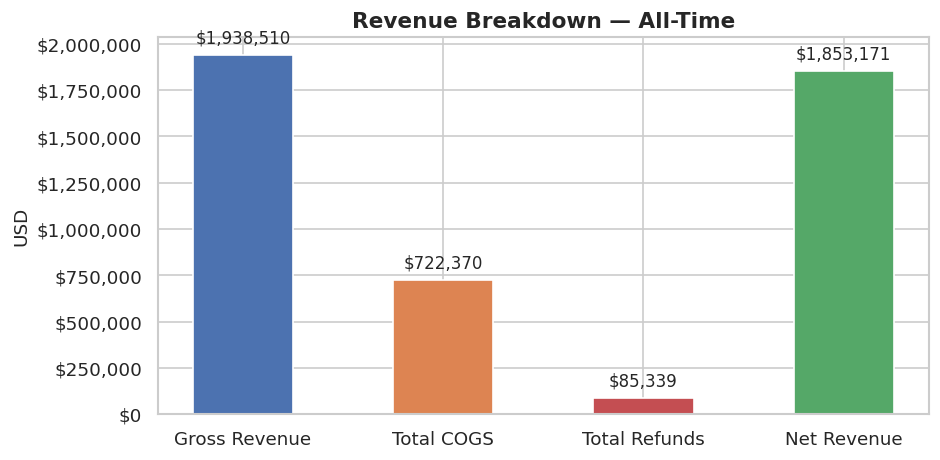

In [15]:
row    = sales_overview.iloc[0]
labels = ['Gross Revenue', 'Total COGS', 'Total Refunds', 'Net Revenue']
values = [row.gross_revenue, row.total_cogs, row.total_refunds, row.net_revenue]
colors = ['#4C72B0', '#DD8452', '#C44E52', '#55A868']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, values, color=colors, width=0.5)
ax.bar_label(bars, fmt='${:,.0f}', padding=5, fontsize=10)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Revenue Breakdown — All-Time', fontweight='bold')
ax.set_ylabel('USD')

plt.tight_layout()
plt.show()

**4.2 Yearly Performance Summary**

In [16]:
yearly_trends = con_duck.execute("""
SELECT
    YEAR(o.created_at) AS year,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price_usd), 2) AS revenue,
    ROUND(SUM(oi.price_usd - oi.cogs_usd), 2) AS gross_profit,
    ROUND(SUM(oi.price_usd) / NULLIF(COUNT(DISTINCT o.order_id),0), 2) AS aov,
    ROUND(SUM(oi.price_usd - oi.cogs_usd) / NULLIF(SUM(oi.price_usd),0) * 100, 2) AS profit_margin_pct,
    ROUND(
        (SUM(oi.price_usd) - LAG(SUM(oi.price_usd)) OVER (ORDER BY YEAR(o.created_at)))
        / NULLIF(LAG(SUM(oi.price_usd)) OVER (ORDER BY YEAR(o.created_at)), 0) * 100, 2
    ) AS revenue_growth_pct
FROM orders AS o JOIN order_items AS oi
ON o.order_id = oi.order_id
GROUP BY 1 ORDER BY 1
""").df()

display(yearly_trends)

,year,total_orders,revenue,gross_profit,aov,profit_margin_pct,revenue_growth_pct
0,2012,2586,129274.14,78873.0,49.99,61.01,NaN
1,2013,7447,393247.87,241596.5,52.81,61.44,204.20
2,2014,16860,1075612.19,679722.5,63.80,63.19,173.52
3,2015,5420,340375.55,215947.5,62.80,63.44,-68.36


**Chart — Yearly Revenue & Gross Profit**

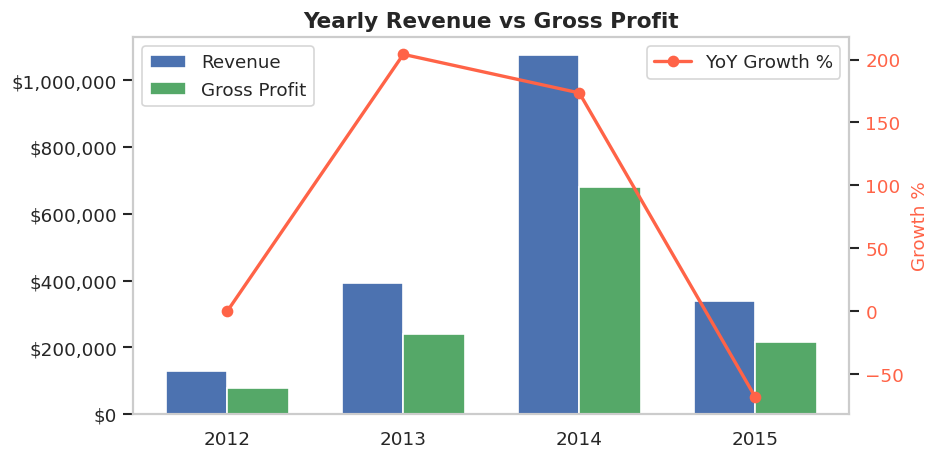

In [17]:
fig, ax1 = plt.subplots(figsize=(8, 4))
x, w = yearly_trends['year'].astype(str), 0.35
pos  = range(len(x))

ax1.bar([p-w/2 for p in pos], yearly_trends['revenue'], width=w, label='Revenue', color='#4C72B0')
ax1.bar([p+w/2 for p in pos], yearly_trends['gross_profit'], width=w, label='Gross Profit', color='#55A868')
ax1.set_xticks(pos); ax1.set_xticklabels(x)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.set_title('Yearly Revenue vs Gross Profit', fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(False)

ax2 = ax1.twinx()
growth = yearly_trends['revenue_growth_pct'].fillna(0)
ax2.plot(pos, growth, color='tomato', marker='o', linewidth=2, label='YoY Growth %')
ax2.set_ylabel('Growth %', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.legend(loc='upper right')
ax2.grid(False)

plt.tight_layout()
plt.show()

**4.3 Monthly Revenue & Growth Trends**

In [18]:
monthly_trends = con_duck.execute("""
    SELECT
        DATE_TRUNC('month', o.created_at) AS month,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(SUM(oi.price_usd), 2) AS revenue,
        ROUND(SUM(oi.price_usd - oi.cogs_usd), 2) AS gross_profit,
        ROUND(SUM(oi.price_usd) / COUNT(DISTINCT o.order_id), 2) AS aov
    FROM orders AS o JOIN order_items oi
    ON o.order_id = oi.order_id
    GROUP BY 1 ORDER BY 1
""").df()

monthly_trends['month'] = pd.to_datetime(monthly_trends['month'])
monthly_trends['revenue_growth_pct'] = monthly_trends['revenue'].pct_change() * 100

display(monthly_trends)

,month,total_orders,revenue,gross_profit,aov,revenue_growth_pct
0,2012-03-01,60,2999.40,1830.0,49.99,NaN
1,2012-04-01,99,4949.01,3019.5,49.99,65.000000
2,2012-05-01,108,5398.92,3294.0,49.99,9.090909
3,2012-06-01,140,6998.60,4270.0,49.99,29.629630
4,2012-07-01,169,8448.31,5154.5,49.99,20.714286
5,2012-08-01,228,11397.72,6954.0,49.99,34.911243
6,2012-09-01,287,14347.13,8753.5,49.99,25.877193
7,2012-10-01,371,18546.29,11315.5,49.99,29.268293
8,2012-11-01,618,30893.82,18849.0,49.99,66.576819
9,2012-12-01,506,25294.94,15433.0,49.99,-18.122977


**Chart — Monthly Revenue Trend (2012–2015)**

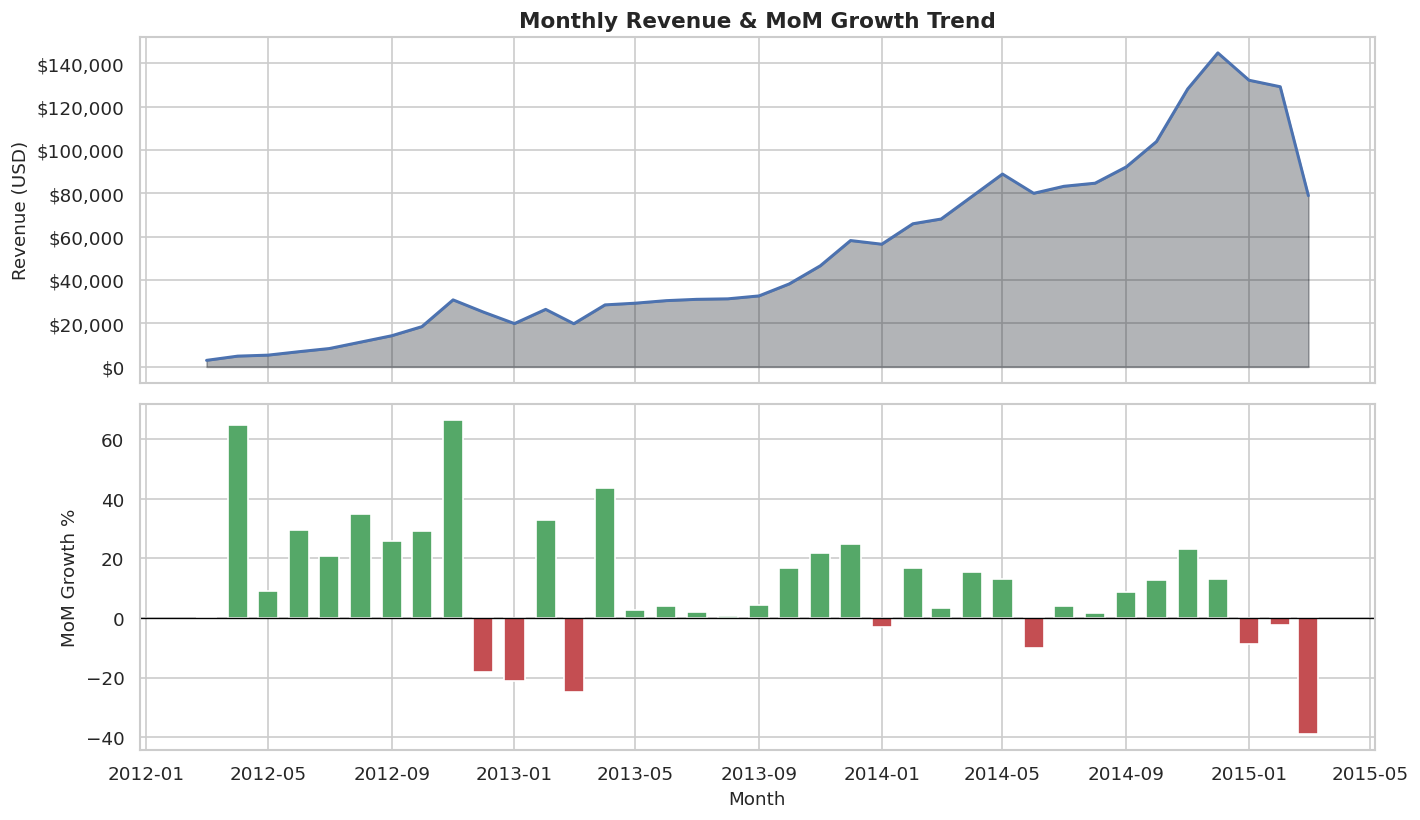

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.fill_between(monthly_trends['month'], monthly_trends['revenue'], alpha=0.3, color="#010711")
ax1.plot(monthly_trends['month'], monthly_trends['revenue'], color='#4C72B0', linewidth=1.8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.set_ylabel('Revenue (USD)')
ax1.set_title('Monthly Revenue & MoM Growth Trend', fontweight='bold')

colors_bar = ['#C44E52' if v < 0 else '#55A868'
              for v in monthly_trends['revenue_growth_pct'].fillna(0)]
ax2.bar(monthly_trends['month'], monthly_trends['revenue_growth_pct'].fillna(0),
        color=colors_bar, width=20)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('MoM Growth %')
ax2.set_xlabel('Month')

plt.tight_layout()
plt.show()

**4.4 Top Products by Revenue & Margin**

In [20]:
top_products = con_duck.execute("""
    SELECT
        p.product_name,
        COUNT(oi.order_item_id) AS items_sold,
        ROUND(SUM(oi.price_usd), 2) AS revenue,
        ROUND(SUM(oi.price_usd - oi.cogs_usd), 2) AS gross_profit,
        ROUND((SUM(oi.price_usd - oi.cogs_usd) / SUM(oi.price_usd)) * 100, 2) AS margin_pct
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY 1 ORDER BY revenue DESC
""").df()

display(top_products)

,product_name,items_sold,revenue,gross_profit,margin_pct
0,The Original Mr. Fuzzy,24226,1211057.74,738893.0,61.01
1,The Forever Love Bear,5796,347702.04,217350.0,62.51
2,The Birthday Sugar Panda,4985,229260.15,157027.5,68.49
3,The Hudson River Mini bear,5018,150489.82,102869.0,68.36


**Chart — Product Revenue & Gross Margin %**

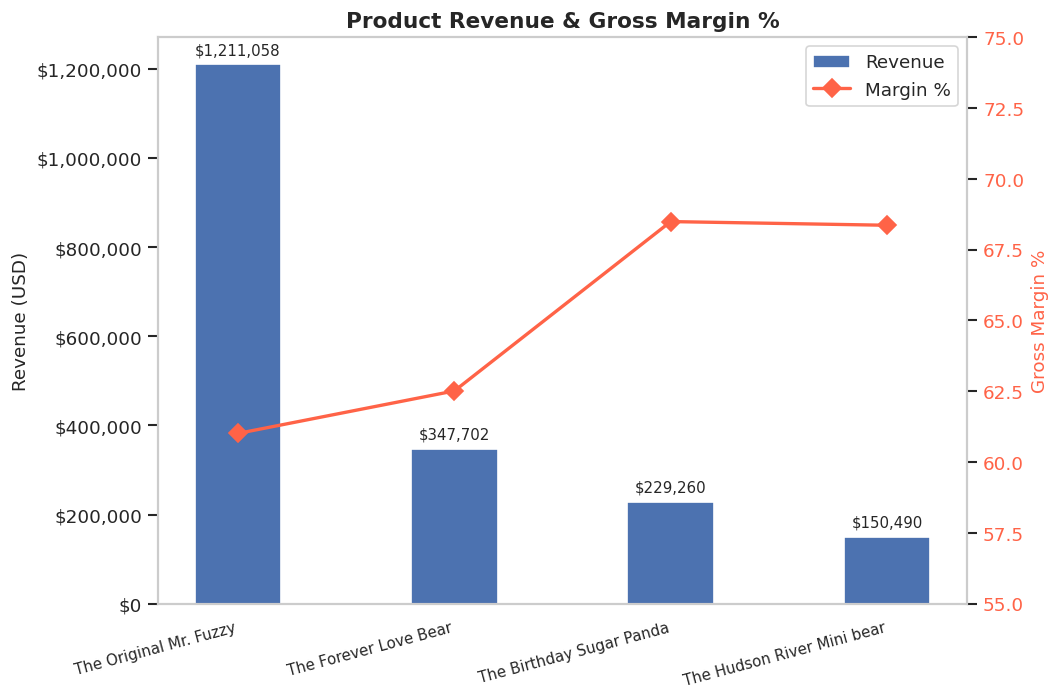

In [21]:
fig, ax1 = plt.subplots(figsize=(9, 6))
x = range(len(top_products))

bars = ax1.bar(x, top_products['revenue'], width=0.4, color='#4C72B0', label='Revenue')
ax1.bar_label(bars, fmt='${:,.0f}', padding=4, fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels(top_products['product_name'], rotation=15, ha='right', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.set_ylabel('Revenue (USD)')
ax1.set_title('Product Revenue & Gross Margin %', fontweight='bold')
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(x, top_products['margin_pct'], color='tomato', marker='D',
         linewidth=2, markersize=8, label='Margin %')
ax2.set_ylabel('Gross Margin %', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(55, 75)
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2)

plt.tight_layout()
plt.show()

**4.5 Traffic Source Efficiency (Conversion Rate)**

In [22]:
traffic_efficiency = con_duck.execute("""
    SELECT
        s.utm_source,
        s.utm_campaign,
        COUNT(DISTINCT s.website_session_id) AS total_sessions,
        COUNT(DISTINCT o.order_id)           AS total_orders,
        ROUND(COUNT(DISTINCT o.order_id)*100.0 / COUNT(DISTINCT s.website_session_id), 2) AS conv_rate,
        ROUND(SUM(o.price_usd), 2)           AS gross_revenue
    FROM website_sessions s
    LEFT JOIN orders o ON s.website_session_id = o.website_session_id
    GROUP BY 1, 2 ORDER BY gross_revenue DESC
""").df()

display(traffic_efficiency)

,utm_source,utm_campaign,total_sessions,total_orders,conv_rate,gross_revenue
0,gsearch,nonbrand,282706,18822,6.66,1124414.21
1,NULL,NULL,83328,6118,7.34,371433.03
2,bsearch,nonbrand,54909,3818,6.95,225563.48
3,gsearch,brand,33329,2511,7.53,151730.68
4,bsearch,brand,7914,701,8.86,43109.02
5,socialbook,desktop_targeted,5590,288,5.15,18516.10
6,socialbook,pilot,5095,55,1.08,3743.23


**Chart — Traffic Source: Sessions vs Conversion Rate**

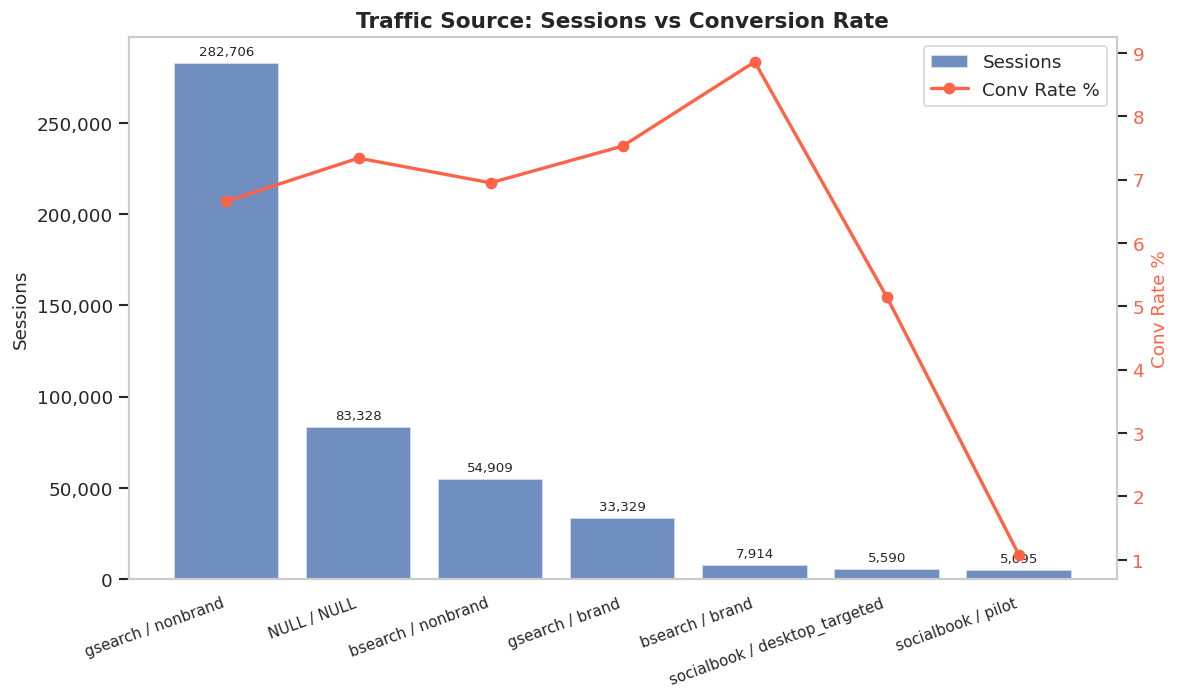

In [23]:
te = traffic_efficiency.copy()
te['label'] = te['utm_source'].fillna('direct') + ' / ' + te['utm_campaign'].fillna('direct')

fig, ax1 = plt.subplots(figsize=(10, 6))
x = range(len(te))

bars = ax1.bar(x, te['total_sessions'], color='#4C72B0', alpha=0.8, label='Sessions')
ax1.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=8)
ax1.set_xticks(x)
ax1.set_xticklabels(te['label'], rotation=20, ha='right', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax1.set_ylabel('Sessions')
ax1.set_title('Traffic Source: Sessions vs Conversion Rate', fontweight='bold')
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(x, te['conv_rate'], color='tomato', marker='o', linewidth=2, label='Conv Rate %')
ax2.set_ylabel('Conv Rate %', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')

plt.tight_layout()
plt.show()

**4.6 Device Performance Gap**

In [24]:
device_performance = con_duck.execute("""
    SELECT
        s.device_type,
        COUNT(DISTINCT s.website_session_id) AS sessions,
        COUNT(DISTINCT o.order_id)           AS orders,
        ROUND(COUNT(DISTINCT o.order_id)*100.0 / COUNT(DISTINCT s.website_session_id), 2) AS conv_rate
    FROM website_sessions s
    LEFT JOIN orders o ON s.website_session_id = o.website_session_id
    GROUP BY 1
""").df()

display(device_performance)

,device_type,sessions,orders,conv_rate
0,mobile,145844,4508,3.09
1,desktop,327027,27805,8.50


**Chart — Device Performance: Mobile vs Desktop**

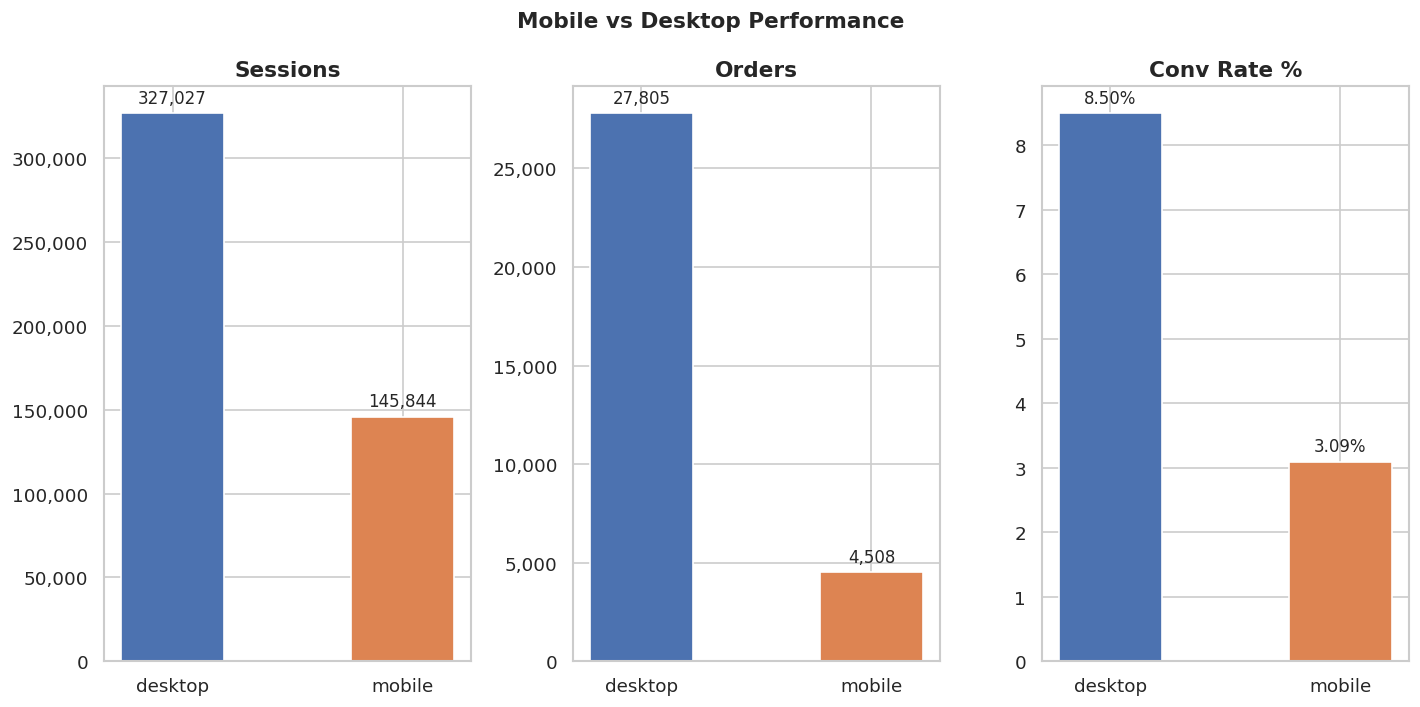

In [25]:
dp     = device_performance.sort_values('device_type')
colors = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
for ax, (col, title) in zip(axes, [('sessions','Sessions'),('orders','Orders'),('conv_rate','Conv Rate %')]):
    bars = ax.bar(dp['device_type'], dp[col], color=colors, width=0.45)
    ax.bar_label(bars,
                 labels=[f'{v:,.0f}' if col!='conv_rate' else f'{v:.2f}%' for v in dp[col]],
                 padding=4, fontsize=10)
    ax.set_title(title, fontweight='bold')
    if col != 'conv_rate':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

fig.suptitle('Mobile vs Desktop Performance', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

### 5. Micro-Level Analysis

#### Group 1 — Revenue & Profitability Deep Dive

**Q1 — In November and December 2014 (peak season), what is the difference in profit margin between 'The Original Mr. Fuzzy' and 'The Birthday Sugar Panda', and which product was more profitable after accounting for refunds?**

In [12]:
q1 = con_duck.execute("""
    SELECT
        p.product_name,
        SUM(oi.price_usd) AS gross_revenue,
        SUM(COALESCE(oir.refund_amount_usd, 0)) AS total_refunds,
        SUM(oi.price_usd - oi.cogs_usd) AS gross_profit
    FROM order_items AS oi 
    JOIN products AS p USING (product_id)
    JOIN orders AS o USING (order_id)
    LEFT JOIN order_item_refunds AS oir USING (order_item_id)
    WHERE o.created_at BETWEEN '2014-11-01' AND '2014-12-31'
      AND p.product_name IN ('The Original Mr. Fuzzy', 'The Birthday Sugar Panda')
    GROUP BY 1
""").df()
q1['net_margin_pct'] = ((q1['gross_profit'] - q1['total_refunds']) / q1['gross_revenue']) * 100


fig = make_subplots(rows=1, cols=3, 
                    subplot_titles=('Gross Revenue ($)', 'Total Refunds ($)', 'Net Margin (%)'))

fig.add_trace(go.Bar(x=q1['product_name'], y=q1['gross_revenue'], name='Revenue',
                     text=q1['gross_revenue'], texttemplate='$%{text:,.0f}', textposition='outside'), row=1, col=1)
fig.add_trace(go.Bar(x=q1['product_name'], y=q1['total_refunds'], name='Refunds',
                     text=q1['total_refunds'], texttemplate='$%{text:,.0f}', textposition='outside'), row=1, col=2)
fig.add_trace(go.Bar(x=q1['product_name'], y=q1['net_margin_pct'], name='Margin',
                     text=q1['net_margin_pct'], texttemplate='%{text:.2f}%', textposition='outside'), row=1, col=3)

fig.update_layout(
    title_text='Peak Season Performance (2014) - Interactive Dashboard',
    title_font_size=20,
    showlegend=False,
    height=500,
    template='plotly_white'
)

fig.update_yaxes(tickprefix="$", row=1, col=1)
fig.update_yaxes(tickprefix="$", row=1, col=2)
fig.update_yaxes(ticksuffix="%", row=1, col=3)

fig.show()

**Q2 — Between July and September 2013 (post 204% growth spike), which products had a disproportionately high refund rate relative to their sales volume?**

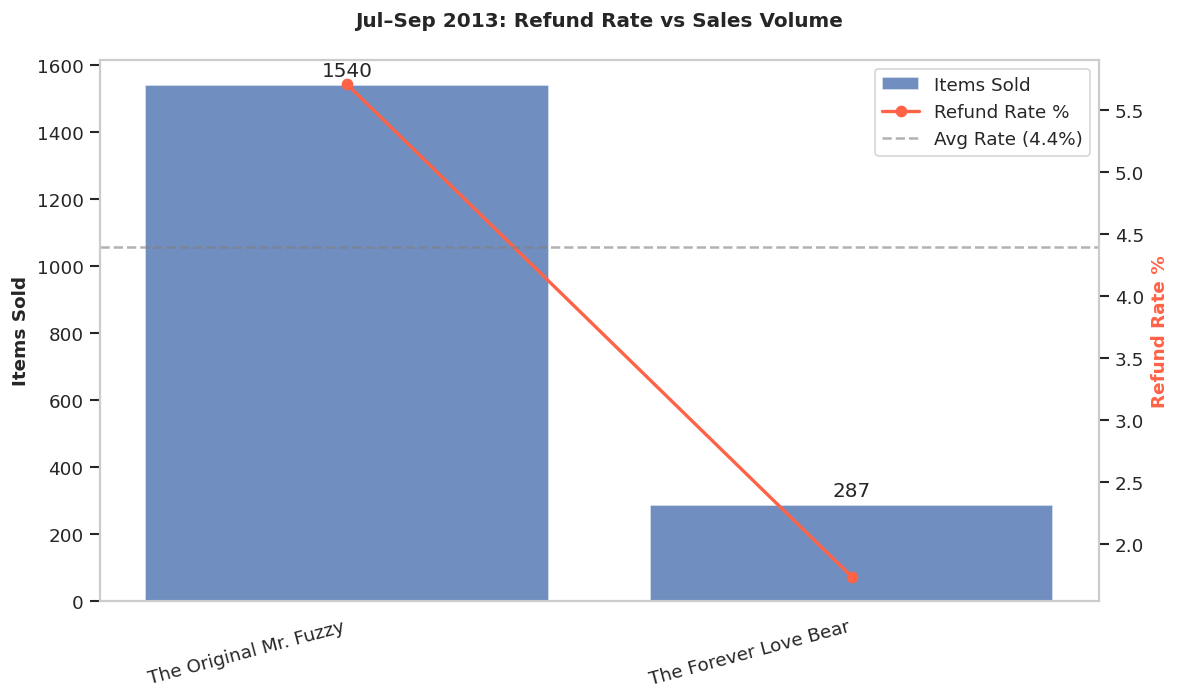

In [ ]:
q2 = con_duck.execute("""
    SELECT
        product_name,
        COUNT(oi.order_item_id) AS items_sold,
        COUNT(oir.order_item_refund_id) AS refunds,
        ROUND(COUNT(oir.order_item_refund_id) * 100.0 / NULLIF(COUNT(oi.order_item_id), 0), 2) AS refund_rate_pct
    FROM order_items oi
    JOIN products USING (product_id)
    JOIN orders o USING (order_id)
    LEFT JOIN order_item_refunds oir USING (order_item_id)
    WHERE o.created_at BETWEEN '2013-07-01' AND '2013-09-30'
    GROUP BY 1 
    ORDER BY refund_rate_pct DESC
""").df()


fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(q2['product_name'], q2['items_sold'], color='#4C72B0', alpha=0.8, label='Items Sold')
ax1.bar_label(bars, padding=3)
ax1.set_ylabel('Items Sold', fontweight='bold')
ax1.set_xticklabels(q2['product_name'], rotation=15, ha='right')
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(q2['product_name'], q2['refund_rate_pct'], color='tomato', marker='o', lw=2, label='Refund Rate %')
ax2.axhline(4.4, color='gray', ls='--', alpha=0.6, label='Avg Rate (4.4%)')
ax2.set_ylabel('Refund Rate %', color='tomato', fontweight='bold')
ax2.grid(False)

fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.title('Jul–Sep 2013: Refund Rate vs Sales Volume', fontsize=12, fontweight='bold', pad=20)
plt.grid(visible=False)
plt.tight_layout()
plt.show()

**Q3 — In 2014 (the highest revenue year at $1.07M), which three months generated the most gross profit, and did their AOV exceed the yearly average of $63.80?**

In [ ]:
q3 = con_duck.execute("""
    SELECT
        DATE_TRUNC('month', o.created_at::TIMESTAMP)::DATE AS month,
        COUNT(DISTINCT o.order_id) AS total_orders,
        SUM(oi.price_usd) AS revenue,
        SUM(oi.price_usd - oi.cogs_usd) AS gross_profit,
        ROUND(SUM(oi.price_usd) / NULLIF(COUNT(DISTINCT o.order_id), 0), 2) AS aov
    FROM orders AS o 
    JOIN order_items oi USING (order_id)
    WHERE o.created_at::TIMESTAMP BETWEEN '2014-01-01' AND '2014-12-31'
    GROUP BY 1 
    ORDER BY 1
""").df()
q3['month'] = pd.to_datetime(q3['month'])
q3['month_str'] = q3['month'].dt.strftime('%b %Y')
top3_profit_val = q3['gross_profit'].nlargest(3).min()
aov_avg = 63.80

fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Monthly Gross Profit ($)', 'AOV vs Benchmark ($)'))

fig.add_trace(
    go.Bar(x=q3['month_str'], y=q3['gross_profit'],
           marker_color=['#C44E52' if v >= top3_profit_val else '#4C72B0' for v in q3['gross_profit']],
           text=q3['gross_profit'], texttemplate='$%{text:,.0f}', textposition='outside'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=q3['month_str'], y=q3['aov'],
           marker_color=['#C44E52' if v > aov_avg else '#55A868' for v in q3['aov']],
           text=q3['aov'], texttemplate='$%{text:.2f}', textposition='outside'),
    row=1, col=2
)

fig.add_hline(y=aov_avg, line_dash="dash", line_color="navy", row=1, col=2)

fig.update_layout(title_text='2014 Performance: Profit & AOV (Interactive)', template='plotly_white', showlegend=False)
fig.update_yaxes(tickprefix="$")
fig.show()

#### Group 2 — Product Performance

**Q4 — Despite ranking 4th in total revenue, were there specific weeks in 2014 where 'The Hudson River Mini Bear' outsold 'The Forever Love Bear'?**

In [ ]:
q4 = """
    SELECT
        DATE_TRUNC('week', o.created_at::TIMESTAMP)::DATE AS week_start,
        p.product_name,
        COUNT(oi.order_item_id) AS items_sold
    FROM order_items AS oi JOIN products AS p USING (product_id)
    JOIN orders AS o USING (order_id)
    WHERE o.created_at::TIMESTAMP BETWEEN '2014-01-01' AND '2014-12-31'
      AND (p.product_name ILIKE '%Mini Bear%' OR p.product_name ILIKE '%Love Bear%')
    GROUP BY 1, 2 
    ORDER BY 1
"""
df = con_duck.execute(q4).df()

fig = px.line(df, x='week_start', y='items_sold', color='product_name',
              title='2014 Weekly Sales: Mini Bear vs Love Bear',
              color_discrete_map={
                  'The Hudson River Mini Bear': '#4C72B0',
                  'The Loving Sugar Love Bear': '#DD8452'
              },
              labels={'week_start': 'Week Start', 'items_sold': 'Units Sold', 'product_name': 'Product'})


pivot = df.pivot(index='week_start', columns='product_name', values='items_sold').fillna(0)
mini_col = [c for c in pivot.columns if 'Mini' in c][0]
love_col = [c for c in pivot.columns if 'Love' in c][0]

fig.add_trace(go.Scatter(
    x=pivot.index, 
    y=pivot[mini_col],
    fill='tonexty',
    fillcolor='rgba(0, 255, 0, 0.1)',
    line_color='rgba(255,255,255,0)',
    name=f'{mini_col} Dominance',
    showlegend=True
))

fig.update_layout(
    hovermode='x unified',
    template='plotly_white',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

**Q5 — After the launch of 'The Birthday Sugar Panda' in early 2014, how many days did it take to reach its first 100 orders?**

In [ ]:
q5 = con_duck.execute("""
    SELECT
        o.created_at::TIMESTAMP AS created_at,
        ROW_NUMBER() OVER (ORDER BY o.created_at) AS order_num
    FROM order_items AS oi 
    JOIN products AS p USING (product_id)
    JOIN orders AS o USING (order_id)
    WHERE p.product_name = 'The Birthday Sugar Panda'
    ORDER BY o.created_at
""").df()
launch_date = q5['created_at'].min()
order_100_date = q5[q5['order_num'] == 100]['created_at'].iloc[0]
days_to_100 = (order_100_date - launch_date).days

launch_ts = launch_date.timestamp() * 1000
order_100_ts = order_100_date.timestamp() * 1000

fig = px.area(q5, x='created_at', y='order_num', 
              title="Product Launch Velocity: 'The Birthday Sugar Panda'",
              labels={'created_at': 'Timeline', 'order_num': 'Cumulative Orders'})

fig.add_vline(x=launch_ts, line_dash="dash", line_color="green",
              annotation_text=f"Launch: {launch_date.date()}", 
              annotation_position="top left")

fig.add_vline(x=order_100_ts, line_dash="dash", line_color="tomato",
              annotation_text=f"100th Order: {order_100_date.date()} ({days_to_100} days)", 
              annotation_position="top right")

fig.update_traces(line_color='#4C72B0', fillcolor='rgba(76, 114, 176, 0.2)')
fig.update_layout(template='plotly_white', hovermode='x unified')

fig.show()

**Q6 — In Q4 2014 specifically, what was the cross-sell rate (orders with more than one item), and which product combinations were most common?**

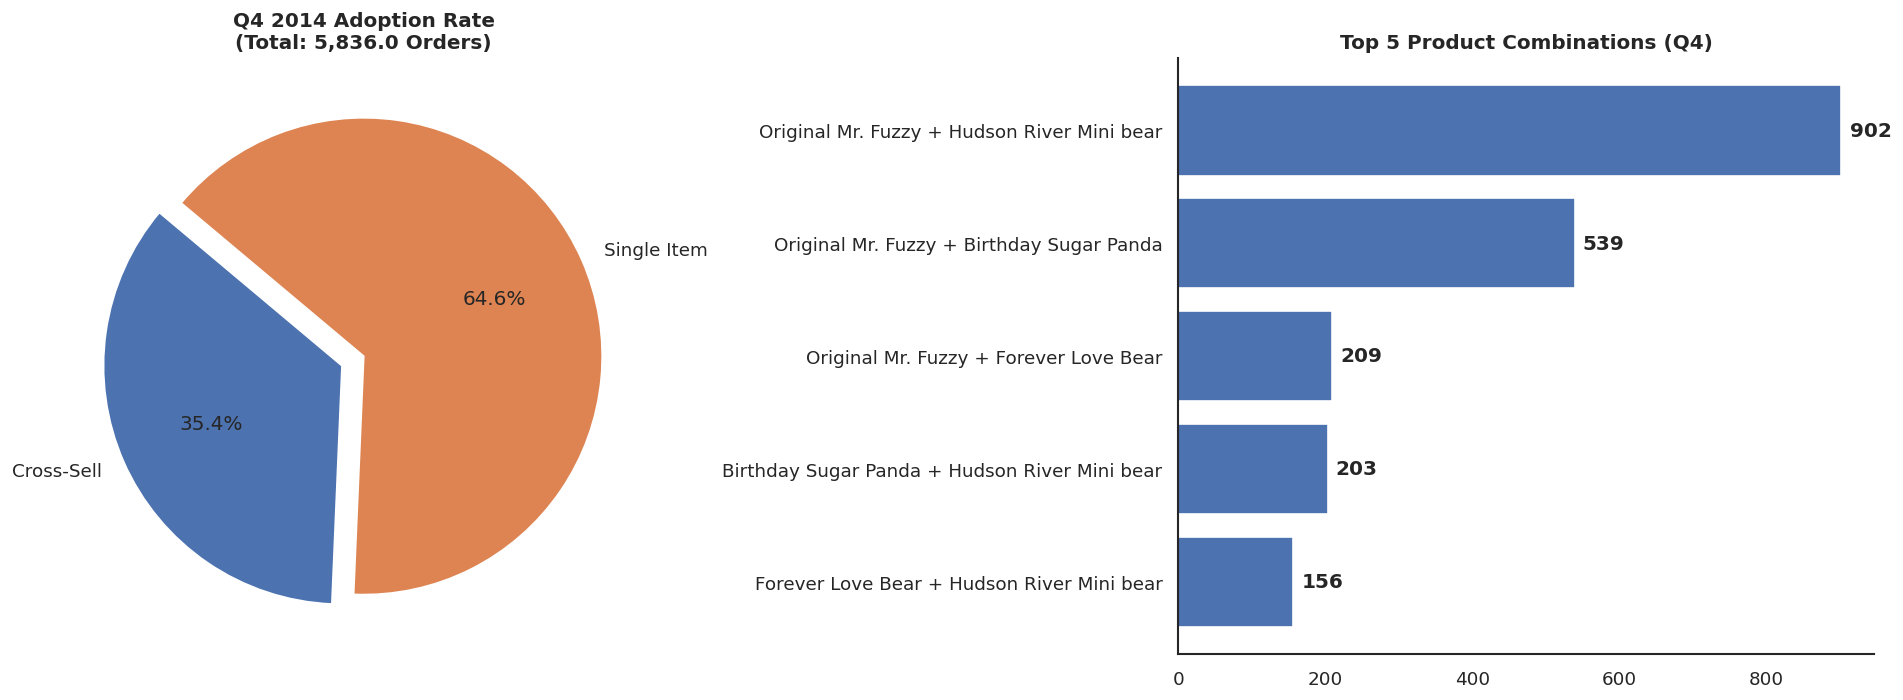

In [ ]:
query_rate = """
    WITH order_metrics AS (
        SELECT order_id, COUNT(order_item_id) AS items_count
        FROM order_items
        JOIN orders o USING (order_id)
        WHERE o.created_at BETWEEN '2014-10-01' AND '2014-12-31'
        GROUP BY 1
    )
    SELECT 
        COUNT(*) AS total_orders,
        COUNT(CASE WHEN items_count > 1 THEN 1 END) AS multi_item_orders,
        ROUND(COUNT(CASE WHEN items_count > 1 THEN 1 END) * 100.0 / NULLIF(COUNT(*), 0), 2) AS cross_sell_pct
    FROM order_metrics
"""
query_combos = """
    SELECT
        REPLACE(p1.product_name, 'The ', '') || ' + ' || 
        REPLACE(p2.product_name, 'The ', '') AS combo_label,
        COUNT(*) AS combo_count
    FROM order_items oi1
    JOIN order_items oi2 ON oi1.order_id = oi2.order_id AND oi1.product_id < oi2.product_id
    JOIN products p1     ON oi1.product_id = p1.product_id
    JOIN products p2     ON oi2.product_id = p2.product_id
    JOIN orders o        ON oi1.order_id   = o.order_id
    WHERE o.created_at BETWEEN '2014-10-01' AND '2014-12-31'
    GROUP BY 1 
    ORDER BY 2 DESC
    LIMIT 5
"""
df_rate = con_duck.execute(query_rate).df()
df_combos = con_duck.execute(query_combos).df()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

rate_data = df_rate.iloc[0]
sizes = [rate_data['multi_item_orders'], rate_data['total_orders'] - rate_data['multi_item_orders']]
ax1.pie(sizes, labels=['Cross-Sell', 'Single Item'], autopct='%1.1f%%', 
        startangle=140, colors=['#4C72B0', '#DD8452'], explode=(0.1, 0))
ax1.set_title(f"Q4 2014 Adoption Rate\n(Total: {rate_data['total_orders']:,} Orders)", fontweight='bold')

bars = ax2.barh(df_combos['combo_label'], df_combos['combo_count'], color='#4C72B0')
ax2.bar_label(bars, padding=5, fontweight='bold')
ax2.invert_yaxis()
ax2.set_title('Top 5 Product Combinations (Q4)', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

#### Group 3 — Traffic & Conversion

**Q7 — In October and November 2014, did gsearch nonbrand maintain its all-time conversion rate of 6.66%, or was there a seasonal improvement or decline?**

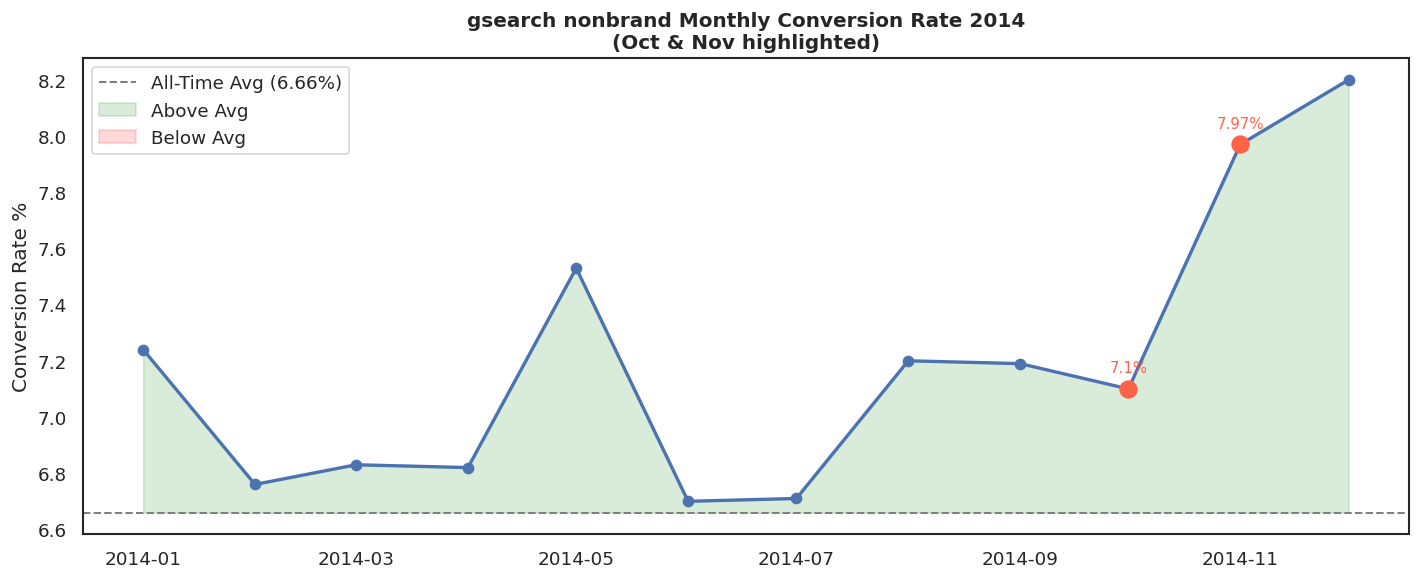

In [ ]:
q7 = con_duck.execute("""
    SELECT
        DATE_TRUNC('month', s.created_at) AS month,
        COUNT(DISTINCT s.website_session_id) AS sessions,
        COUNT(DISTINCT o.order_id) AS orders,
        ROUND(COUNT(DISTINCT o.order_id) * 100.0 / COUNT(DISTINCT s.website_session_id), 2) AS conv_rate_pct
    FROM website_sessions AS s LEFT JOIN orders AS o
    ON s.website_session_id = o.website_session_id
    WHERE s.utm_source   = 'gsearch'
      AND s.utm_campaign = 'nonbrand'
      AND YEAR(s.created_at) = 2014
    GROUP BY 1 ORDER BY 1
""").df()

q7['month'] = pd.to_datetime(q7['month'])
baseline  = 6.66
highlight = q7[q7['month'].dt.month.isin([10, 11])]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(q7['month'], q7['conv_rate_pct'], color='#4C72B0', marker='o', linewidth=2)
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.2, label=f'All-Time Avg ({baseline}%)')

for _, row in highlight.iterrows():
    ax.scatter(row['month'], row['conv_rate_pct'], color='tomato', s=100, zorder=5)
    ax.annotate(f"{row['conv_rate_pct']}%", (row['month'], row['conv_rate_pct']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9, color='tomato')

ax.fill_between(q7['month'], q7['conv_rate_pct'], baseline,
                where=(q7['conv_rate_pct'] > baseline), alpha=0.15, color='green', label='Above Avg')
ax.fill_between(q7['month'], q7['conv_rate_pct'], baseline,
                where=(q7['conv_rate_pct'] < baseline), alpha=0.15, color='red',   label='Below Avg')
ax.set_title('gsearch nonbrand Monthly Conversion Rate 2014\n(Oct & Nov highlighted)', fontweight='bold')
ax.set_ylabel('Conversion Rate %'); ax.legend(); ax.grid(False)
plt.tight_layout(); plt.show()

**Q8 — In the first three months of 2013, what was the conversion rate gap between desktop and mobile for the gsearch nonbrand campaign specifically?**

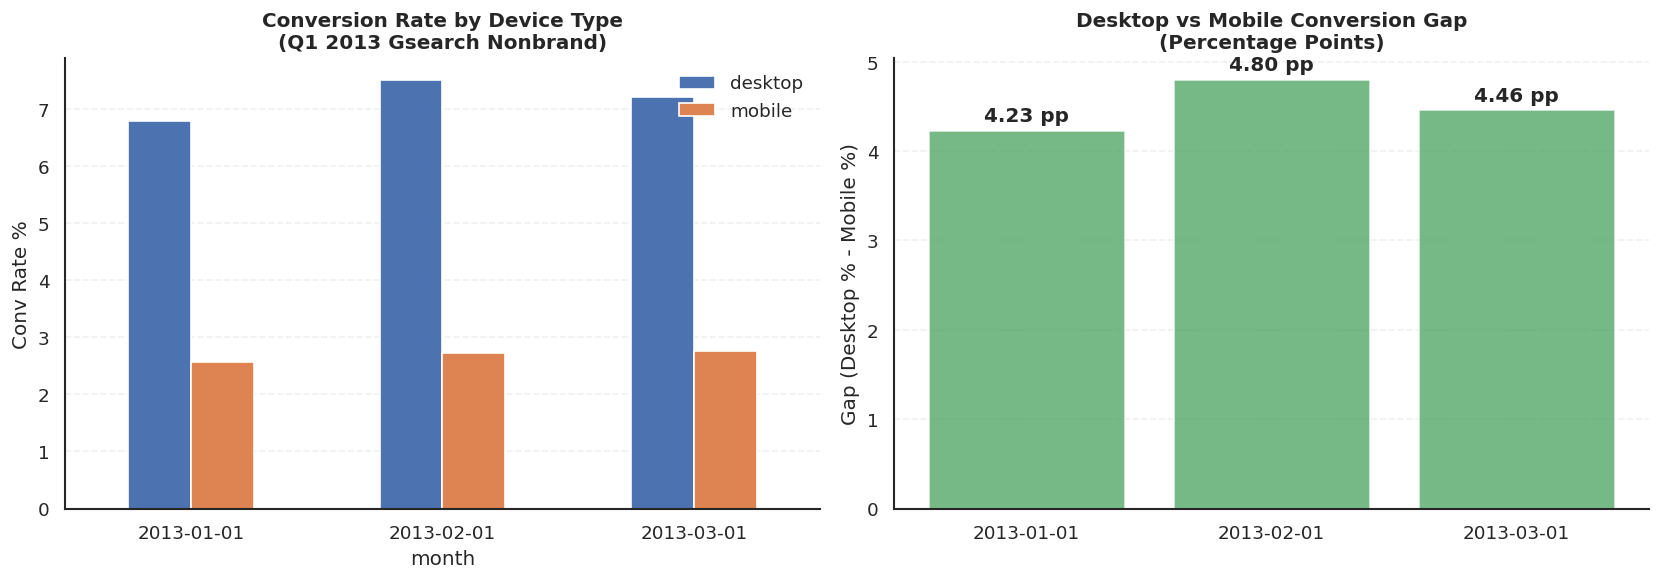

In [ ]:
q8 = con_duck.execute("""
    SELECT
        DATE_TRUNC('month', s.created_at)::DATE AS month,
        s.device_type,
        COUNT(DISTINCT s.website_session_id) AS sessions,
        COUNT(DISTINCT o.order_id) AS orders,
        ROUND(COUNT(DISTINCT o.order_id) * 100.0 / NULLIF(COUNT(DISTINCT s.website_session_id), 0), 2) AS conv_rate_pct
    FROM website_sessions s
    LEFT JOIN orders o USING (website_session_id)
    WHERE s.utm_source = 'gsearch'
      AND s.utm_campaign = 'nonbrand'
      AND s.created_at BETWEEN '2013-01-01' AND '2013-03-31'
    GROUP BY 1, 2 
    ORDER BY 1, 2
""").df()
pivot9 = q8.pivot(index='month', columns='device_type', values='conv_rate_pct').fillna(0)
pivot9.index = pivot9.index.astype(str)
pivot9['gap'] = pivot9['desktop'] - pivot9['mobile']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

pivot9[['desktop', 'mobile']].plot(kind='bar', ax=ax1, color=['#4C72B0', '#DD8452'], rot=0)
ax1.set_title('Conversion Rate by Device Type\n(Q1 2013 Gsearch Nonbrand)', fontweight='bold')
ax1.set_ylabel('Conv Rate %')
ax1.legend(frameon=False)

gap_colors = ['#C44E52' if v > 5 else '#55A868' for v in pivot9['gap']]
bars2 = ax2.bar(pivot9.index, pivot9['gap'], color=gap_colors, alpha=0.8)

ax2.bar_label(bars2, fmt='%.2f pp', padding=3, fontweight='bold')
ax2.set_title('Desktop vs Mobile Conversion Gap\n(Percentage Points)', fontweight='bold')
ax2.set_ylabel('Gap (Desktop % - Mobile %)')

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### Group 4 — Device & Session Behavior

**Q9 — In 2012, was the mobile vs desktop conversion rate gap already as wide as the all-time gap (3.09% vs 8.50%), or were the two devices closer in performance at the start?**

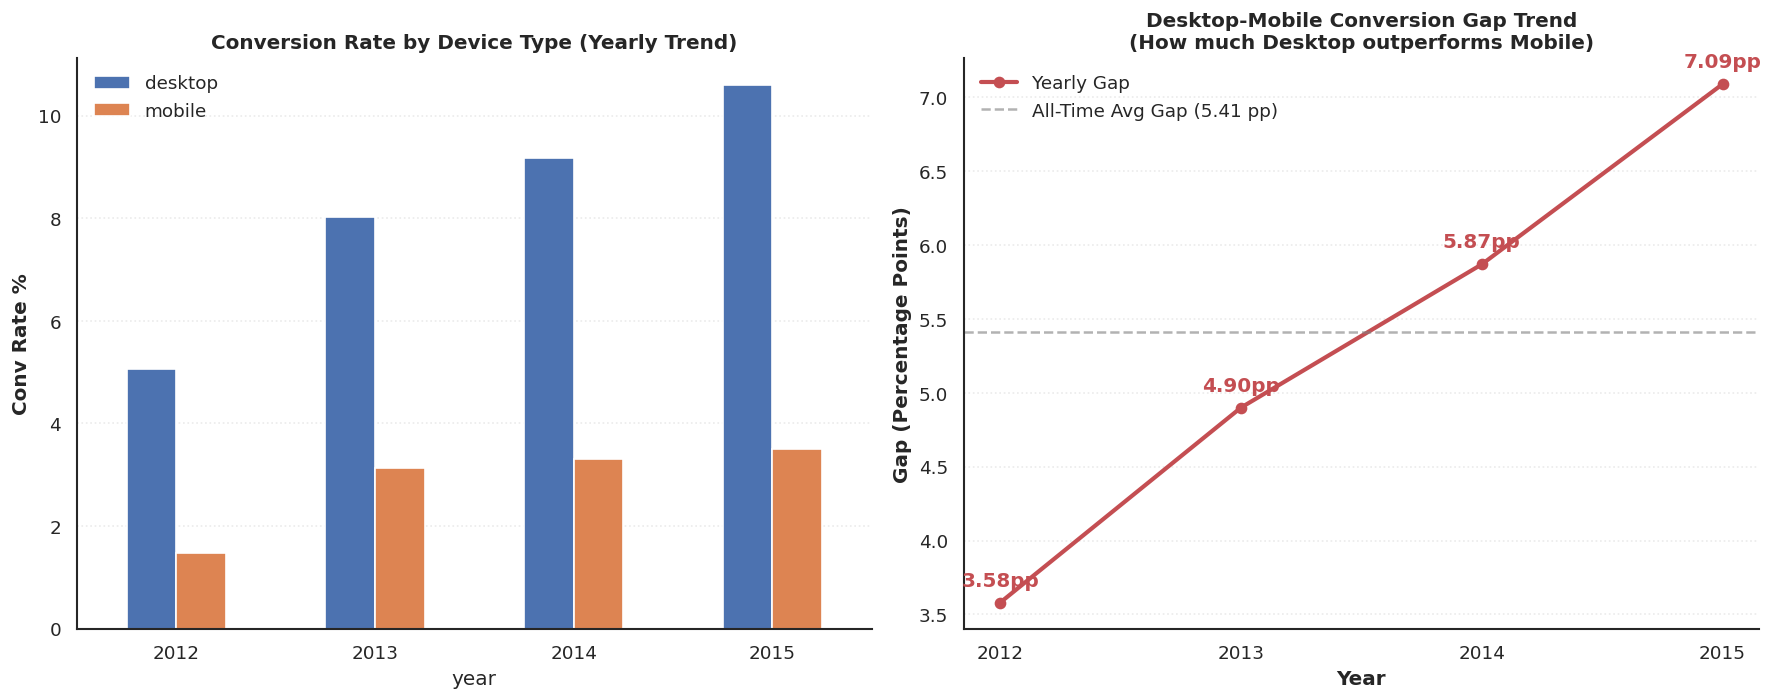

In [ ]:
q9 = con_duck.execute("""
    SELECT
        EXTRACT(YEAR FROM s.created_at) AS year,
        s.device_type,
        COUNT(DISTINCT s.website_session_id)                                          AS sessions,
        COUNT(DISTINCT o.order_id)                                                    AS orders,
        ROUND(COUNT(DISTINCT o.order_id) * 100.0
              / COUNT(DISTINCT s.website_session_id), 2)                              AS conv_rate_pct
    FROM website_sessions s
    LEFT JOIN orders o ON s.website_session_id = o.website_session_id
    GROUP BY 1, 2 ORDER BY 1, 2
""").df()
pivot10 = q9.pivot(index='year', columns='device_type', values='conv_rate_pct').fillna(0)
pivot10['gap'] = pivot10['desktop'] - pivot10['mobile']
avg_gap = 5.41

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

pivot10[['desktop', 'mobile']].plot(kind='bar', ax=ax1, color=['#4C72B0', '#DD8452'], rot=0)
ax1.set_title('Conversion Rate by Device Type (Yearly Trend)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Conv Rate %', fontweight='bold')
ax1.legend(frameon=False, loc='upper left')


ax2.plot(pivot10.index.astype(str), pivot10['gap'], color='#C44E52', marker='o', lw=2.5, label='Yearly Gap')
ax2.axhline(avg_gap, color='gray', ls='--', alpha=0.6, label=f'All-Time Avg Gap ({avg_gap} pp)')

for year, gap in zip(pivot10.index.astype(str), pivot10['gap']):
    ax2.annotate(f'{gap:.2f}pp', 
                 (year, gap), 
                 textcoords='offset points', xytext=(0, 10), 
                 ha='center', fontweight='bold', color='#C44E52')

ax2.set_title('Desktop-Mobile Conversion Gap Trend\n(How much Desktop outperforms Mobile)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Gap (Percentage Points)', fontweight='bold')
ax2.set_xlabel('Year', fontweight='bold')
ax2.legend(frameon=False)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

**Q10 — In 2014, which day of the week had the highest desktop session volume, and did it also correspond to the highest desktop conversion rate?**

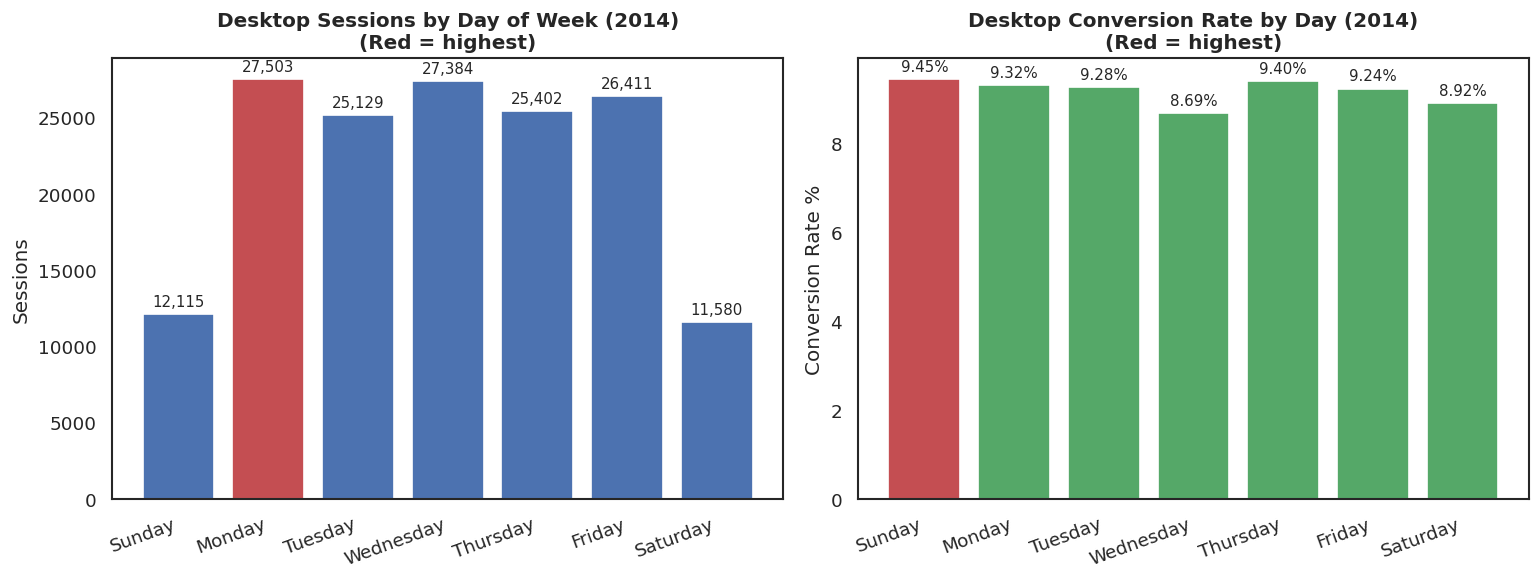

In [ ]:
q10 = con_duck.execute("""
    SELECT
        DAYOFWEEK(s.created_at) AS day_num,
        STRFTIME(s.created_at, '%A') AS day_name,
        COUNT(DISTINCT s.website_session_id) AS sessions,
        COUNT(DISTINCT o.order_id) AS orders,
        ROUND(COUNT(DISTINCT o.order_id) * 100.0
              / COUNT(DISTINCT s.website_session_id), 2) AS conv_rate_pct
    FROM website_sessions s
    LEFT JOIN orders o ON s.website_session_id = o.website_session_id
    WHERE s.device_type = 'desktop'
      AND YEAR(s.created_at) = 2014
    GROUP BY 1, 2 ORDER BY 1
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bar_colors1 = ['#C44E52' if v == q10['sessions'].max() else '#4C72B0' for v in q10['sessions']]
bars1 = ax1.bar(q10['day_name'], q10['sessions'], color=bar_colors1)
ax1.bar_label(bars1, fmt='{:,.0f}', padding=3, fontsize=9)
ax1.set_title('Desktop Sessions by Day of Week (2014)\n(Red = highest)', fontweight='bold')
ax1.set_ylabel('Sessions'); ax1.set_xticklabels(q10['day_name'], rotation=20, ha='right'); ax1.grid(False)

bar_colors2 = ['#C44E52' if v == q10['conv_rate_pct'].max() else '#55A868' for v in q10['conv_rate_pct']]
bars2 = ax2.bar(q10['day_name'], q10['conv_rate_pct'], color=bar_colors2)
ax2.bar_label(bars2, fmt='{:.2f}%', padding=3, fontsize=9)
ax2.set_title('Desktop Conversion Rate by Day (2014)\n(Red = highest)', fontweight='bold')
ax2.set_ylabel('Conversion Rate %'); ax2.set_xticklabels(q10['day_name'], rotation=20, ha='right'); ax2.grid(False)

plt.tight_layout()
plt.show()

#### Group 5 — Refunds & Risk

**Q11 — What was the monthly refund distribution across 2014, and were there any months with a refund rate spike above the all-time average of 4.4%?**

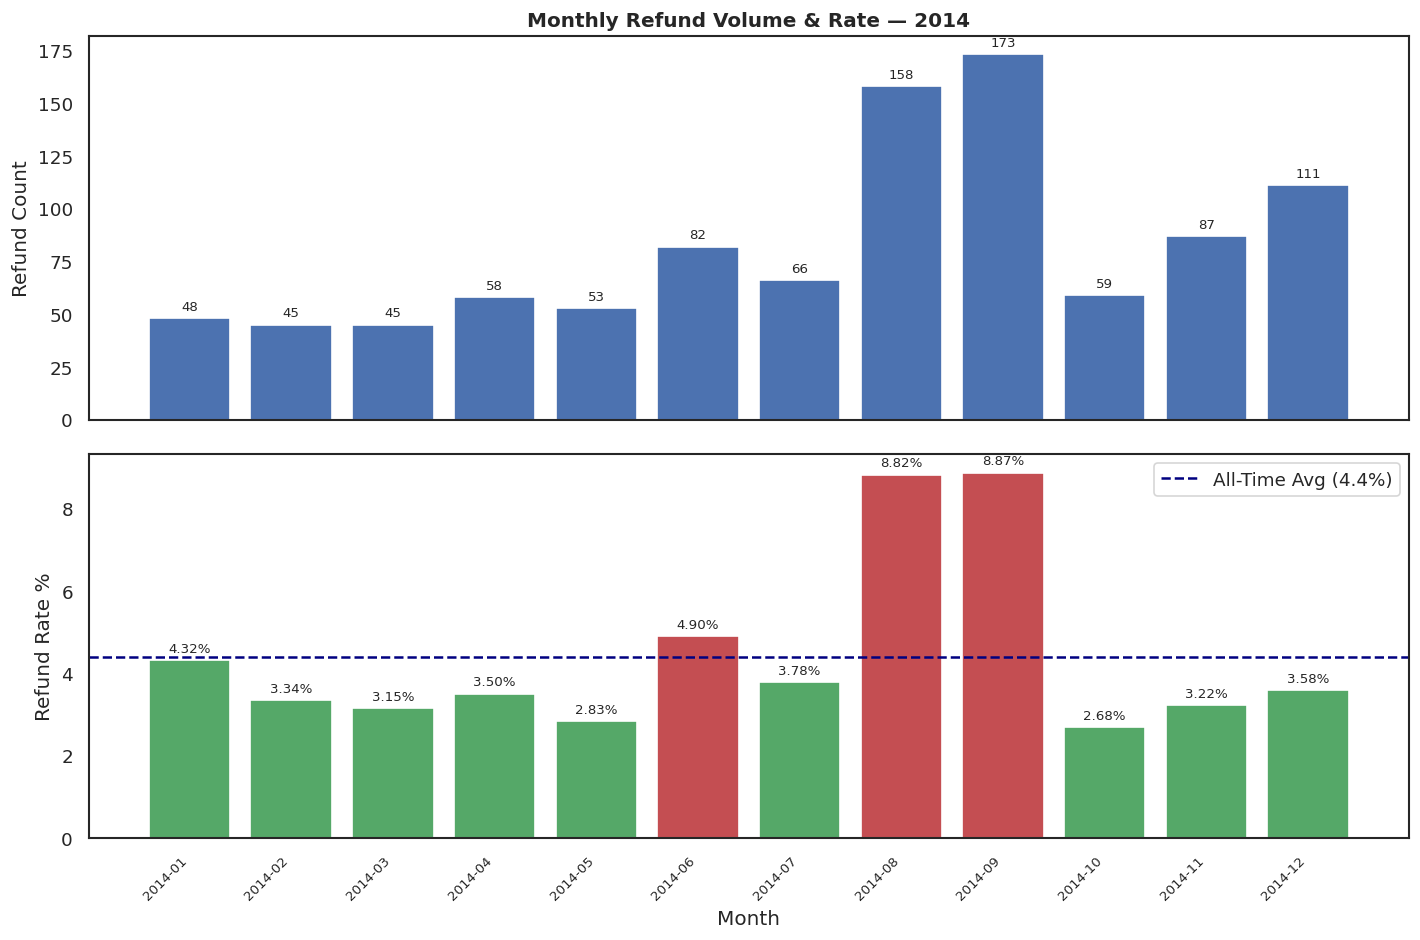

In [ ]:
q11 = con_duck.execute("""
    SELECT
        STRFTIME(o.created_at, '%Y-%m')                                                  AS month,
        COUNT(oi.order_item_id)                                                          AS items_sold,
        COUNT(oir.order_item_refund_id)                                                  AS refunds,
        ROUND(COUNT(oir.order_item_refund_id) * 100.0 / COUNT(oi.order_item_id), 2)      AS refund_rate_pct,
        ROUND(COALESCE(SUM(oir.refund_amount_usd), 0), 2)                                AS refund_amount
    FROM order_items oi
    JOIN orders o                    ON oi.order_id      = o.order_id
    LEFT JOIN order_item_refunds oir ON oi.order_item_id = oir.order_item_id
    WHERE YEAR(o.created_at) = 2014
    GROUP BY 1 ORDER BY 1
""").df()

avg_refund = 4.4
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

bars1 = ax1.bar(q11['month'], q11['refunds'], color='#4C72B0')
ax1.bar_label(bars1, fmt='{:,.0f}', padding=3, fontsize=8)
ax1.set_ylabel('Refund Count'); ax1.grid(False)
ax1.set_title('Monthly Refund Volume & Rate — 2014', fontweight='bold')

spike_colors = ['#C44E52' if v > avg_refund else '#55A868' for v in q11['refund_rate_pct']]
bars2 = ax2.bar(q11['month'], q11['refund_rate_pct'], color=spike_colors)
ax2.bar_label(bars2, fmt='{:.2f}%', padding=3, fontsize=8)
ax2.axhline(avg_refund, color='navy', linestyle='--', linewidth=1.5, label=f'All-Time Avg ({avg_refund}%)')
ax2.set_ylabel('Refund Rate %'); ax2.set_xlabel('Month')
ax2.set_xticklabels(q11['month'], rotation=45, ha='right', fontsize=8)
ax2.legend()
ax2.grid(False)

plt.tight_layout()
plt.show()

**Q12 — What is the individual refund rate for 'The Original Mr. Fuzzy' (highest volume, 24,226 items) vs 'The Birthday Sugar Panda' (highest margin, 68.49%)?**

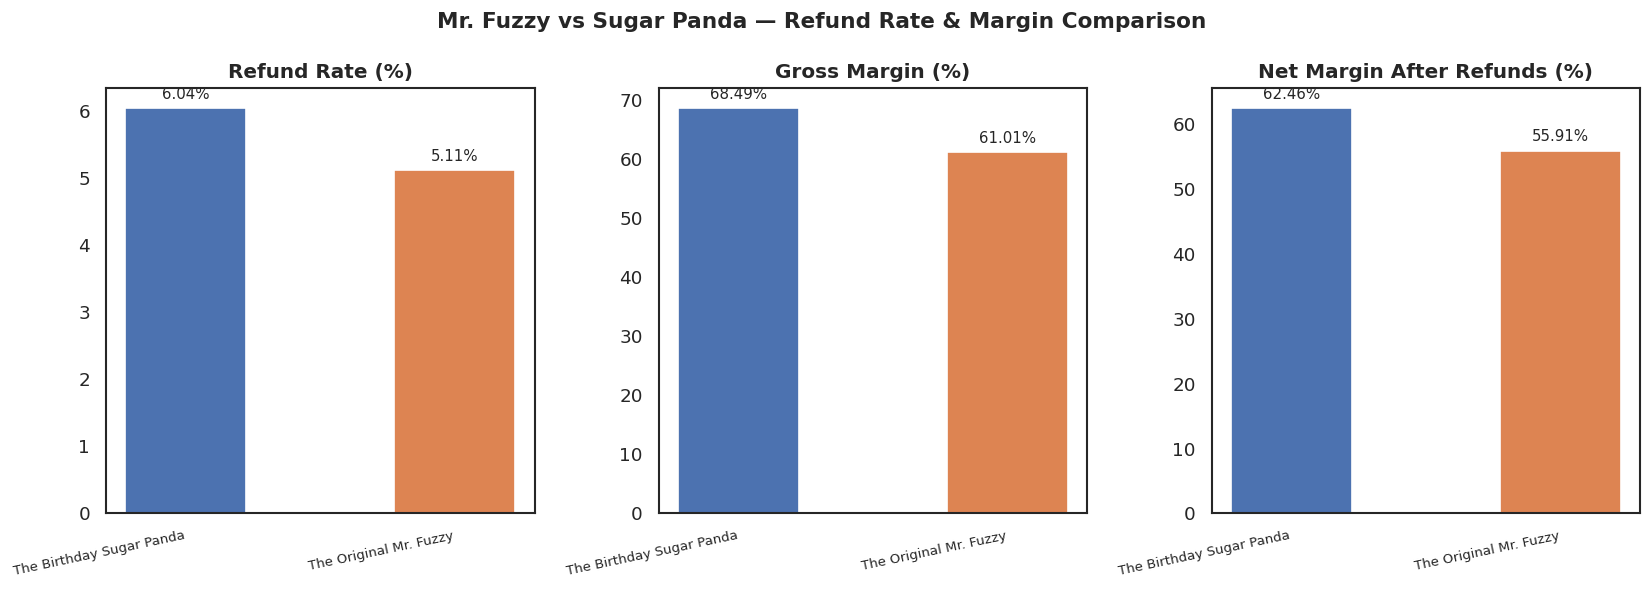

In [ ]:
q12 = con_duck.execute("""
    SELECT
        p.product_name,
        COUNT(oi.order_item_id) AS items_sold,
        COUNT(oir.order_item_refund_id) AS refunds,
        ROUND(COUNT(oir.order_item_refund_id) * 100.0 / COUNT(oi.order_item_id), 2) AS refund_rate_pct,
        ROUND(COALESCE(SUM(oir.refund_amount_usd), 0), 2) AS total_refund_usd,
        ROUND((SUM(oi.price_usd - oi.cogs_usd) / SUM(oi.price_usd)) * 100, 2) AS gross_margin_pct,
        ROUND(
            (SUM(oi.price_usd - oi.cogs_usd) - COALESCE(SUM(oir.refund_amount_usd), 0))
            / NULLIF(SUM(oi.price_usd), 0) * 100, 2
        ) AS net_margin_pct
    FROM order_items oi AS JOIN products AS p USING (product_id)
    LEFT JOIN order_item_refunds AS oir USING (order_item_id)
    WHERE p.product_name IN ('The Original Mr. Fuzzy', 'The Birthday Sugar Panda')
    GROUP BY 1
""").df()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors  = ['#4C72B0', '#DD8452']
metrics = [
    ('refund_rate_pct',  'Refund Rate (%)',               '{:.2f}%'),
    ('gross_margin_pct', 'Gross Margin (%)',               '{:.2f}%'),
    ('net_margin_pct',   'Net Margin After Refunds (%)',   '{:.2f}%'),
]
for ax, (col, title, fmt) in zip(axes, metrics):
    bars = ax.bar(q12['product_name'], q12[col], color=colors, width=0.45)
    ax.bar_label(bars, labels=[fmt.format(v) for v in q12[col]], padding=4, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(q12['product_name'], rotation=12, ha='right', fontsize=8)
    ax.grid(False)
fig.suptitle('Mr. Fuzzy vs Sugar Panda — Refund Rate & Margin Comparison', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

#### Group 6 — Growth & Anomalies

**Q13 — The 2015 data ends in March, causing a misleading −68.36% YoY growth. What is the true Q1-to-Q1 growth rate when comparing Q1 2015 vs Q1 2014?**

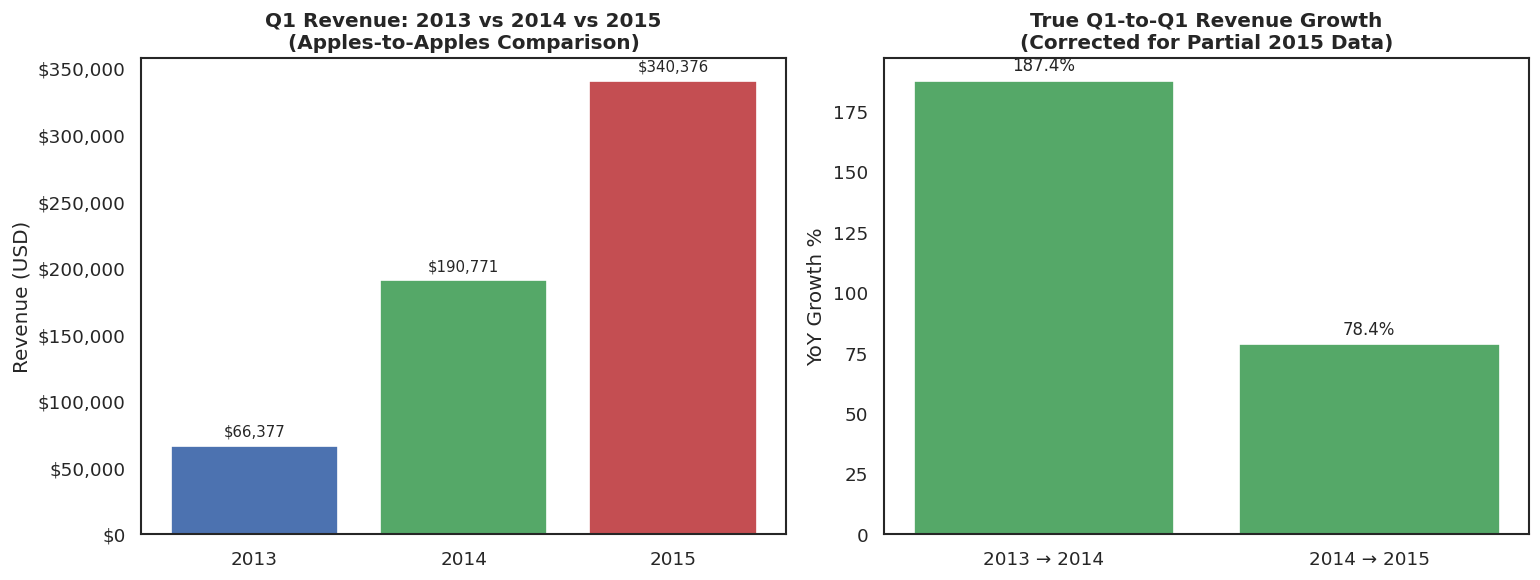

In [ ]:
q13 = con_duck.execute("""
    SELECT
        EXTRACT(YEAR FROM o.created_at) AS year,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(SUM(oi.price_usd), 2) AS revenue,
        ROUND(SUM(oi.price_usd - oi.cogs_usd), 2) AS gross_profit,
        ROUND(SUM(oi.price_usd) / COUNT(DISTINCT o.order_id), 2) AS aov
    FROM orders AS o JOIN order_items AS oi
    ON o.order_id = oi.order_id
    WHERE MONTH(o.created_at) BETWEEN 1 AND 3
      AND YEAR(o.created_at) IN (2013, 2014, 2015)
    GROUP BY 1 ORDER BY 1
""").df()
q13['revenue_growth_pct'] = q13['revenue'].pct_change() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors13 = ['#4C72B0', '#55A868', '#C44E52']
bars1 = ax1.bar(q13['year'].astype(str), q13['revenue'], color=colors13)
ax1.bar_label(bars1, fmt='${:,.0f}', padding=4, fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.set_title('Q1 Revenue: 2013 vs 2014 vs 2015\n(Apples-to-Apples Comparison)', fontweight='bold')
ax1.set_ylabel('Revenue (USD)'); ax1.grid(False)

growth_vals   = q13['revenue_growth_pct'].dropna().values
growth_labels = [f'{q13["year"].iloc[i-1]} → {q13["year"].iloc[i]}' for i in range(1, len(q13))]
g_colors      = ['#55A868' if v > 0 else '#C44E52' for v in growth_vals]
bars2 = ax2.bar(growth_labels, growth_vals, color=g_colors)
ax2.bar_label(bars2, fmt='{:.1f}%', padding=4, fontsize=10)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('True Q1-to-Q1 Revenue Growth\n(Corrected for Partial 2015 Data)', fontweight='bold')
ax2.set_ylabel('YoY Growth %'); ax2.grid(False)

plt.tight_layout()
plt.show()

**Q14 — What were the top 5 highest revenue days across all three years, and are they clustered in the same seasonal periods or spread across different windows?**

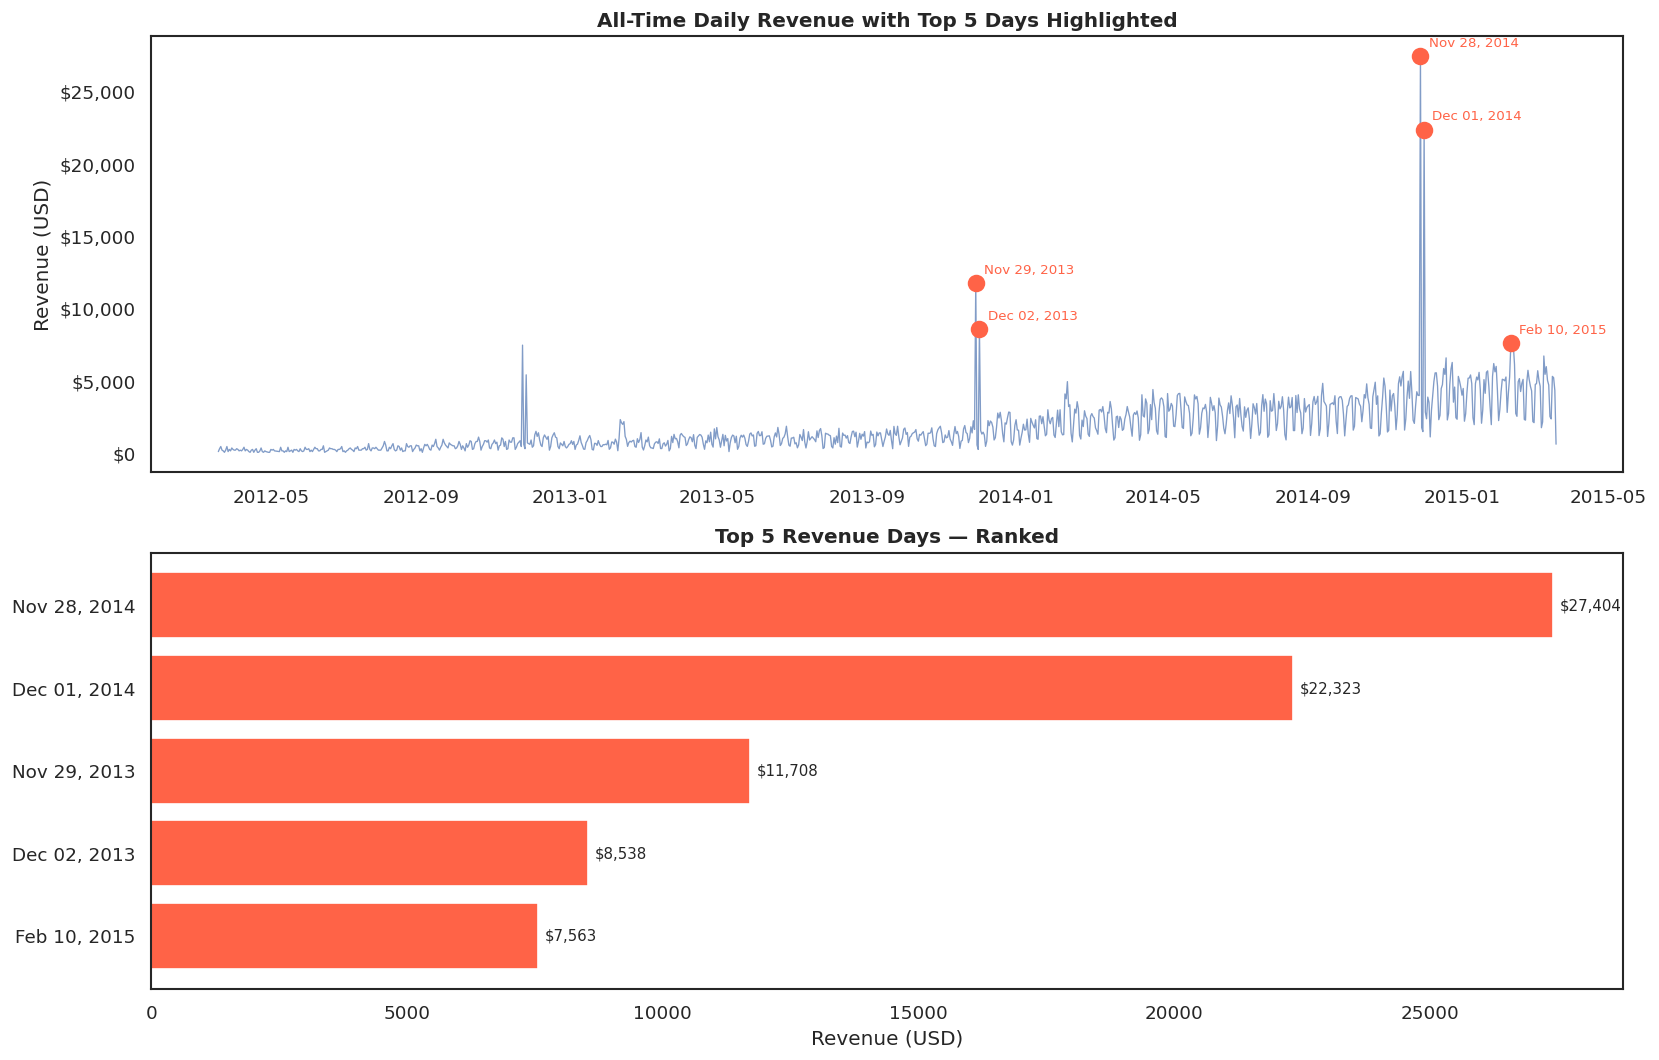

In [82]:
q14 = con_duck.execute("""
    SELECT
        DATE_TRUNC('day', o.created_at) AS sale_date,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(SUM(oi.price_usd), 2) AS revenue,
        ROUND(SUM(oi.price_usd - oi.cogs_usd), 2) AS gross_profit
    FROM orders AS o JOIN order_items AS oi
    ON o.order_id = oi.order_id
    GROUP BY 1 ORDER BY revenue DESC
    LIMIT 5
""").df()
q14['sale_date'] = pd.to_datetime(q14['sale_date'])
q14['label']     = q14['sale_date'].dt.strftime('%b %d, %Y')

daily_all = con_duck.execute("""
    SELECT
        DATE_TRUNC('day', o.created_at) AS sale_date,
        ROUND(SUM(oi.price_usd), 2)      AS revenue
    FROM orders o JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY 1 ORDER BY 1
""").df()
daily_all['sale_date'] = pd.to_datetime(daily_all['sale_date'])


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

ax1.plot(daily_all['sale_date'], daily_all['revenue'], color='#4C72B0', linewidth=0.8, alpha=0.7)
for _, row in q14.iterrows():
    ax1.scatter(row['sale_date'], row['revenue'], color='tomato', s=90, zorder=5)
    ax1.annotate(row['label'], (row['sale_date'], row['revenue']),
                 textcoords='offset points', xytext=(5, 6), fontsize=8, color='tomato')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.set_title('All-Time Daily Revenue with Top 5 Days Highlighted', fontweight='bold')
ax1.set_ylabel('Revenue (USD)'); ax1.grid(False)

bars = ax2.barh(q14['label'], q14['revenue'], color='tomato')
ax2.bar_label(bars, fmt='${:,.0f}', padding=4, fontsize=9)
ax2.invert_yaxis()
ax2.set_title('Top 5 Revenue Days — Ranked', fontweight='bold')
ax2.set_xlabel('Revenue (USD)'); ax2.grid(False)

plt.tight_layout()
plt.show()